In [2]:
import numpy as np

In [7]:
np.load('/home/esli/GenMatter/assets/RDK/config_1/data.npz')['points_data']

array([[[102.      , 435.      ],
        [270.      , 106.      ],
        [ 71.      ,  20.      ],
        ...,
        [ 22.      , 128.      ],
        [290.      , 500.      ],
        [185.      , 478.      ]],

       [[101.989716, 434.9992  ],
        [166.      , 402.      ],
        [ 71.01559 ,  20.047533],
        ...,
        [ 22.07604 , 128.04802 ],
        [290.      , 499.98224 ],
        [184.982   , 477.98187 ]],

       [[101.97986 , 435.0005  ],
        [165.98463 , 402.00003 ],
        [670.      ,  91.      ],
        ...,
        [ 22.150248, 128.09378 ],
        [290.00653 , 499.9691  ],
        [184.96436 , 477.96573 ]],

       ...,

       [[460.      , 113.      ],
        [533.0723  , 191.01701 ],
        [403.02536 , 457.0033  ],
        ...,
        [ 71.02192 , 283.0137  ],
        [540.2071  , 279.0781  ],
        [370.99634 ,  48.055073]],

       [[460.0756  , 112.98943 ],
        [533.10706 , 191.0259  ],
        [403.04547 , 457.005   ],
        .

In [10]:
np.load('/home/esli/GenMatter/assets/RDK/config_1/data.npz')['nn_motion_vectors']

array([[[-1.02844238e-02, -7.93457031e-04],
        [ 1.90390015e+00, -8.00032043e+00],
        [ 1.55868530e-02,  4.75330353e-02],
        ...,
        [ 7.60402679e-02,  4.80194092e-02],
        [ 0.00000000e+00, -1.77612305e-02],
        [-1.80053711e-02, -1.81274414e-02]],

       [[-9.85717773e-03,  1.28173828e-03],
        [-1.53656006e-02,  3.05175781e-05],
        [-5.99110413e+00,  4.58545685e-02],
        ...,
        [ 7.42073059e-02,  4.57611084e-02],
        [ 6.53076172e-03, -1.31530762e-02],
        [-1.76391602e-02, -1.61437988e-02]],

       [[-1.22833252e-02,  3.02124023e-03],
        [-1.75476074e-02,  1.98364258e-03],
        [ 6.46588135e+00, -2.10547638e+00],
        ...,
        [ 3.08829498e+00, -7.93295288e+00],
        [ 2.13623047e-03, -8.78906250e-03],
        [-1.99432373e-02, -1.20239258e-02]],

       ...,

       [[ 4.01147461e+00, -1.10130005e+01],
        [ 3.69873047e-02,  9.91821289e-03],
        [ 2.53601074e-02,  3.29589844e-03],
        ...,
     

In [ ]:
# we can interpolate the true motion vectors using GP, as an alternative model hypothesis that doesn't work 
# so even if it's better, which it won't be, we still have a better model
# cite Gershman's paper for this 

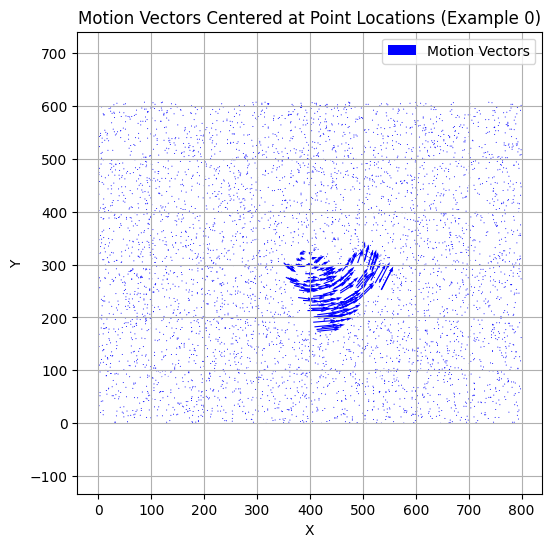

In [24]:
import matplotlib.pyplot as plt

# Load npz file once
data = np.load('/home/esli/GenMatter/assets/RDK/config_1/data.npz')
motion_vectors = data['motion_vectors']    # shape: (N, 5000, 2)
motion_vectors[np.abs(motion_vectors) > 1000] = 0
positions = data['points_data']              # shape: (N, 5000, 2)

# Plot the first example (index 0)
mv_example = motion_vectors[50]   # shape: (5000, 2)
pos_example = positions[50]       # shape: (5000, 2)

plt.figure(figsize=(6, 6))
# Make arrows bigger by reducing the scale (smaller = bigger arrows)
plt.quiver(pos_example[:, 0], pos_example[:, 1], mv_example[:, 0], mv_example[:, 1],
           angles='xy', scale_units='xy', scale=0.2, color='b', label='Motion Vectors')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Motion Vectors Centered at Point Locations (Example 0)')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

In [5]:
# SAM-based oracle using the one-frame model 
# RAFT-style optical flow color visualization, looping through all frames and saving as GIF
# ---
# PATCH: Fix ValueError in GIF saving by ensuring all images are the same size.
# Previous version was transposed and the overlay was not mapped correctly. This version fixes those issues.
# PATCH: Increase flow visibility in the alpha blend by increasing the flow (color layer) contribution.

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import imageio

def make_raft_color_wheel():
    """Creates the RAFT color wheel used for RAFT-style optical flow visualization."""
    colorwheel = []
    for i in range(15):
        colorwheel.append([255, int(255.0*i/15), 0])
    for i in range(6):
        colorwheel.append([255-int(255.0*i/6),255,0])
    for i in range(4):
        colorwheel.append([0,255, int(255.0*i/4)])
    for i in range(11):
        colorwheel.append([0,255-int(255.0*i/11),255])
    for i in range(13):
        colorwheel.append([int(255.0*i/13),0,255])
    for i in range(6):
        colorwheel.append([255,0,255-int(255.0*i/6)])
    return np.array(colorwheel, dtype=np.uint8)

def flow_to_raft_rgb(flow, max_flow=None):
    colorwheel = make_raft_color_wheel()
    ncols = colorwheel.shape[0]
    u = flow[..., 0]
    v = flow[..., 1]
    rad = np.sqrt(u**2 + v**2)
    a = np.arctan2(-v, -u) / np.pi
    fk = (a + 1) / 2 * (ncols - 1)
    k0 = np.floor(fk).astype(int)
    k1 = (k0 + 1) % ncols
    f = fk - k0

    if max_flow is None:
        max_flow = np.percentile(rad, 99)
        if max_flow < 1e-6:
            max_flow = 1.0

    img = np.zeros(flow.shape[:2]+(3,), dtype=np.float32)
    for i in range(3):
        col0 = colorwheel[k0, i] / 255.0
        col1 = colorwheel[k1, i] / 255.0
        col = (1 - f) * col0 + f * col1

        idx = rad <= 1
        col[idx] = 1 - rad[idx] * (1-col[idx])
        col[~idx] *= 0.75

        img[..., i] = col

    img = img * np.clip(rad / max_flow, 0, 1)[..., None]
    img = np.clip(img, 0, 1)
    return (img * 255).astype(np.uint8)

# Load data
data = np.load('/home/esli/GenMatter/assets/RDK/config_1/data.npz')
motion_vectors = data['motion_vectors']
motion_vectors[np.abs(motion_vectors) > 1000] = 0
positions = data['points_data']

N = motion_vectors.shape[0]
images = []

# Get global bounds for consistent GIF area
all_min = np.min(positions, axis=(0,1))
all_max = np.max(positions, axis=(0,1))
margin = 10
min_x, min_y = all_min - margin
max_x, max_y = all_max + margin

# Make integer pixel grid
grid_x, grid_y = np.meshgrid(
    np.arange(int(min_x), int(max_x)), 
    np.arange(int(min_y), int(max_y))
)  # Note: grid_x, grid_y shape is (height, width)
# grid_x, grid_y have (rows, cols) = (height, width)
h, w = grid_x.shape

# Precompute max_flow for all frames for color normalization
max_flow_for_all = 0
for idx in range(N):
    mv = motion_vectors[idx]
    if np.any(np.isnan(mv)): continue
    max_flow_for_all = max(max_flow_for_all, np.percentile(np.hypot(mv[:, 0], mv[:, 1]), 99))
if max_flow_for_all < 1e-6:
    max_flow_for_all = 1.0

for idx in range(N):
    mv = motion_vectors[idx]
    pos = positions[idx]
    # Interpolate to dense grid, careful with axis conventions
    dense_flow = np.zeros((h, w, 2), dtype=np.float32)
    for i in range(2):
        interp = griddata(
            pos,
            mv[:, i],
            (grid_x, grid_y),
            method='cubic',
            fill_value=0
        )
        mask_nan = np.isnan(interp)
        if np.any(mask_nan):
            # fallback to nearest for NaNs
            interp[mask_nan] = griddata(pos, mv[:, i], (grid_x, grid_y), method='nearest', fill_value=0)[mask_nan]
        dense_flow[..., i] = interp

    # NOTE: grid_x, grid_y are (h, w), and positions is xy, so overlaying points requires mapping x->col, y->row.
    flow_img = flow_to_raft_rgb(dense_flow, max_flow=max_flow_for_all)
    
    # Overlay dots using accurate mapping, but increase the flow visibility by blending with higher alpha for the flow
    overlay_img = flow_img.copy()
    # Positions as col, row = x, y
    px = pos[:, 0]
    py = pos[:, 1]
    # Convert to int array pixel indices after subtracting min_x/min_y
    col_idx = np.clip(np.round(px - min_x).astype(int), 0, w-1)
    row_idx = np.clip(np.round(py - min_y).astype(int), 0, h-1)
    
    # Blend white dots with the flow: high flow alpha, lower dot alpha
    white = np.array([255, 255, 255], dtype=np.uint8)
    alpha_flow = 0.85  # previously would be about 0.7 (implicit when overwrite); now make the flow stronger
    alpha_dot = 1.0 - alpha_flow
    for rr, cc in zip(row_idx, col_idx):
        for drow in [-2, -1, 0, 1, 2]:
            for dcol in [-2, -1, 0, 1, 2]:
                r = rr + drow
                c = cc + dcol
                if 0 <= r < h and 0 <= c < w:
                    # blend: result = alpha_flow * flow_img + alpha_dot * white
                    overlay_img[r, c] = (
                        alpha_flow * flow_img[r, c].astype(float) + alpha_dot * white
                    ).clip(0, 255).astype(np.uint8)
    images.append(overlay_img)

# All images same shape; no transpose; overlay is correct.
gif_path = 'interpolated_dense_flow.gif'
imageio.mimsave(gif_path, images, duration=0.2)
print(f"Saved GIF to {gif_path}")


Saved GIF to interpolated_dense_flow.gif


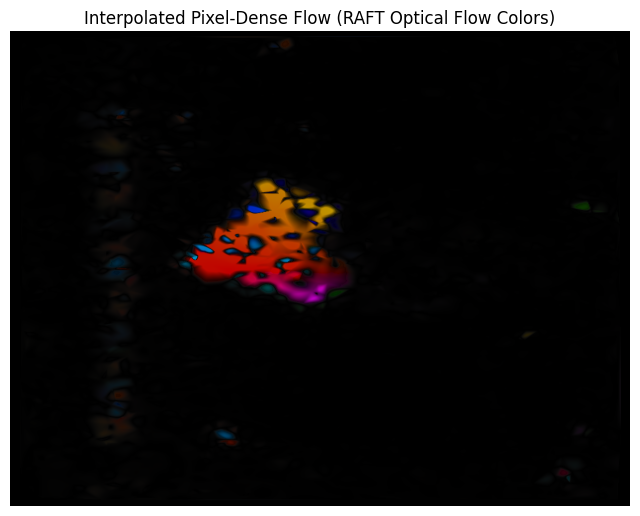

In [5]:
plt.figure(figsize=(8, 8))
plt.imshow(flow_img, origin='lower', extent=[min_x-margin, max_x+margin, min_y-margin, max_y+margin])
plt.title('Interpolated Pixel-Dense Flow (RAFT Optical Flow Colors)')
plt.axis('off')
plt.show()


In [ ]:
# the flow was computed by using the ground truth motion vectors

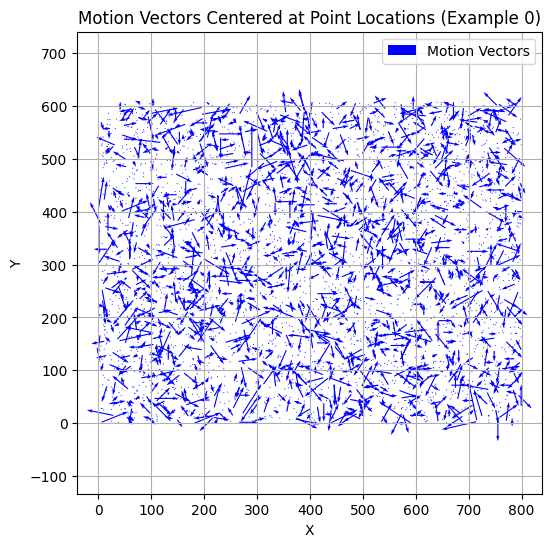

In [12]:
import matplotlib.pyplot as plt

# Load npz file once
data = np.load('/home/esli/GenMatter/assets/RDK/config_1/data.npz')
motion_vectors = data['nn_motion_vectors']    # shape: (N, 5000, 2)
positions = data['points_data']              # shape: (N, 5000, 2)

# Plot the first example (index 0)
mv_example = motion_vectors[0]   # shape: (5000, 2)
pos_example = positions[0]       # shape: (5000, 2)

plt.figure(figsize=(6, 6))
# Make arrows bigger by reducing the scale (smaller = bigger arrows)
plt.quiver(pos_example[:, 0], pos_example[:, 1], mv_example[:, 0], mv_example[:, 1],
           angles='xy', scale_units='xy', scale=0.2, color='b', label='Motion Vectors')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Motion Vectors Centered at Point Locations (Example 0)')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

In [10]:
np.load('/home/esli/GenMatter/assets/RDK/config_1/data.npz')['nn_motion_vectors']

array([[[-1.02844238e-02, -7.93457031e-04],
        [ 1.90390015e+00, -8.00032043e+00],
        [ 1.55868530e-02,  4.75330353e-02],
        ...,
        [ 7.60402679e-02,  4.80194092e-02],
        [ 0.00000000e+00, -1.77612305e-02],
        [-1.80053711e-02, -1.81274414e-02]],

       [[-9.85717773e-03,  1.28173828e-03],
        [-1.53656006e-02,  3.05175781e-05],
        [-5.99110413e+00,  4.58545685e-02],
        ...,
        [ 7.42073059e-02,  4.57611084e-02],
        [ 6.53076172e-03, -1.31530762e-02],
        [-1.76391602e-02, -1.61437988e-02]],

       [[-1.22833252e-02,  3.02124023e-03],
        [-1.75476074e-02,  1.98364258e-03],
        [ 6.46588135e+00, -2.10547638e+00],
        ...,
        [ 3.08829498e+00, -7.93295288e+00],
        [ 2.13623047e-03, -8.78906250e-03],
        [-1.99432373e-02, -1.20239258e-02]],

       ...,

       [[ 4.01147461e+00, -1.10130005e+01],
        [ 3.69873047e-02,  9.91821289e-03],
        [ 2.53601074e-02,  3.29589844e-03],
        ...,
     

In [ ]:
# what happens if we run flow directly on the images? 

In [ ]:
import torch
import torchvision.transforms as transforms
from torchvision.models.optical_flow import raft_large
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
import re

# Load the video
video_path = "/home/esli/GenMatter/assets/from_thomas/scene_00000/texture_00/output.mp4"
cap = cv2.VideoCapture(video_path)

# Check if video opened successfully
if not cap.isOpened():
    raise RuntimeError(f"Error: Could not open video {video_path}")
print(f"Successfully opened video: {video_path}")

# Extract scene and texture names from the video path
scene_match = re.search(r"(scene_\d+)", video_path)
texture_match = re.search(r"(texture_\d+)", video_path)
scene_name = scene_match.group(1) if scene_match else "scene_unknown"
texture_name = texture_match.group(1) if texture_match else "texture_unknown"
output_file_base = f"raft_flows_{scene_name}_{texture_name}"

# Get video properties
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f"Video properties: {width}x{height}, {fps} fps, {frame_count} frames")

# Load pretrained RAFT model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = raft_large(pretrained=True)
model = model.to(device)
model.eval()

# Transform for preprocessing frames
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((520, 960)),  # RAFT expects specific input size
    transforms.ToTensor()
])

# Read all frames into memory (as BGR)
frames = []
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
for i in range(frame_count):
    ret, frame = cap.read()
    if not ret:
        print(f"Warning: Could not read frame {i}")
        break
    frames.append(frame)
cap.release()

print(f"Loaded {len(frames)} frames.")

# Prepare output directory for saving flows
output_dir = "raft_flows"
os.makedirs(output_dir, exist_ok=True)

# Compute optical flow for each consecutive frame pair and store in a single array
all_flows = []
for i in tqdm(range(len(frames) - 1), desc="Extracting RAFT optical flow"):
    frame1_bgr = frames[i]
    frame2_bgr = frames[i + 1]
    # Convert BGR to RGB
    frame1_rgb = cv2.cvtColor(frame1_bgr, cv2.COLOR_BGR2RGB)
    frame2_rgb = cv2.cvtColor(frame2_bgr, cv2.COLOR_BGR2RGB)
    # Preprocess frames
    frame1_tensor = transform(frame1_rgb).unsqueeze(0).to(device)
    frame2_tensor = transform(frame2_rgb).unsqueeze(0).to(device)
    # Run RAFT
    with torch.no_grad():
        flow_predictions = model(frame1_tensor, frame2_tensor)
        flow = flow_predictions[-1]
    # Convert flow to numpy (H, W, 2)
    flow_np = flow[0].cpu().numpy().transpose(1, 2, 0)
    all_flows.append(flow_np)
    # Optionally, save a visualization for the first few pairs
    if i < 3:
        plt.figure(figsize=(15, 5))
        plt.subplot(1, 3, 1)
        plt.imshow(frame1_rgb)
        plt.title(f"Frame {i}")
        plt.axis('off')
        plt.subplot(1, 3, 2)
        plt.imshow(frame2_rgb)
        plt.title(f"Frame {i+1}")
        plt.axis('off')
        plt.subplot(1, 3, 3)
        flow_magnitude = np.sqrt(flow_np[:, :, 0]**2 + flow_np[:, :, 1]**2)
        plt.imshow(flow_magnitude, cmap='hot')
        plt.title("Optical Flow Magnitude")
        plt.colorbar()
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"{output_file_base}_flow_vis_{i:05d}_{i+1:05d}.png"))
        plt.close()

# Stack all flows into a single numpy array of shape (N-1, H, W, 2)
all_flows_np = np.stack(all_flows, axis=0)
# Save the whole array as a single .npy file, named according to scene and texture
output_npz_path = os.path.join(output_dir, f"{output_file_base}.npz")
np.savez(output_npz_path, all_flows_np)
print(f"Saved all {all_flows_np.shape[0]} optical flow fields to {output_npz_path}")


In [ ]:
# Visualize the first flow: color by angle, brightness by magnitude, with a colorbar for angle interpretation
first_flow = all_flows_np[0]  # shape (H, W, 2)
u = first_flow[:, :, 0]
v = first_flow[:, :, 1]
magnitude = np.sqrt(u**2 + v**2)
angle = np.arctan2(v, u)  # radians, range [-pi, pi]

# Normalize angle to [0, 1] for HSV colormap (hue)
hue = (angle + np.pi) / (2 * np.pi)
# Normalize magnitude to [0, 1] for value (brightness)
mag_norm = magnitude / (np.max(magnitude) + 1e-8)
mag_norm = np.clip(mag_norm, 0, 1)

# HSV image: hue=angle, saturation=1, value=magnitude
hsv_img = np.zeros((*hue.shape, 3), dtype=np.float32)
hsv_img[..., 0] = hue          # Hue: angle
hsv_img[..., 1] = 1.0          # Saturation: full
hsv_img[..., 2] = mag_norm     # Value: normalized magnitude

# Convert HSV to RGB for display
try:
    import matplotlib.colors as mcolors
    rgb_img = mcolors.hsv_to_rgb(hsv_img)
except ImportError:
    rgb_img = plt.cm.hsv(hue)[..., :3] * mag_norm[..., None]  # fallback

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(rgb_img)
ax.set_title("First Flow: Color=Angle, Brightness=Magnitude")
ax.axis('off')
plt.tight_layout()

# Add a colorbar for flow angle interpretation
import matplotlib as mpl
from matplotlib.colors import hsv_to_rgb

# Create a colorbar image for angle
angle_ticks = np.linspace(-np.pi, np.pi, 256)
hue_bar = (angle_ticks + np.pi) / (2 * np.pi)
hsv_bar = np.zeros((1, len(hue_bar), 3), dtype=np.float32)
hsv_bar[..., 0] = hue_bar
hsv_bar[..., 1] = 1.0
hsv_bar[..., 2] = 1.0
rgb_bar = hsv_to_rgb(hsv_bar)

# Place the colorbar below the image
from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="5%", pad=0.4)
cb = cax.imshow(rgb_bar, aspect="auto")
cax.set_xticks([0, len(angle_ticks)//4, len(angle_ticks)//2, 3*len(angle_ticks)//4, len(angle_ticks)-1])
cax.set_xticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])
cax.set_yticks([])
cax.set_xlabel("Flow Angle (radians)")
cax.xaxis.set_label_position('bottom')
cax.xaxis.set_ticks_position('bottom')

plt.show()
